In [46]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
 
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix,
)

In [28]:
RANDOM_STATE = 42
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

In [ ]:
DATA_PATH = Path("italian_pipeline_outputs/italian_final_dataset.csv")

df_raw = pd.read_csv(DATA_PATH)

all_nan_cols = [
    c for c in df_raw.columns
    if df_raw[c].isna().all()
]

print("Dropping:", all_nan_cols)

df_raw = df_raw.drop(
    columns=all_nan_cols
)

# =====================================================
# Remove subjects with no audio
# =====================================================

audio_anchor = "mfcc_1_mean"

df = (
    df_raw[
        df_raw[audio_anchor].notna()
    ]
    .copy()
    .reset_index(drop=True)
)

# =====================================================
# Columns NOT used as features
# =====================================================

NON_FEATURE_COLS = {
    "name",
    "surname",
    "label",
    "subject_id",
    "participant_key",
    "participant_folder_key",
    "participant_folder",
    "participant_name",
    "group_folder",
    "name_norm",
    "surname_norm",
    "label_audio"
}

# =====================================================
# Build numeric feature list
# =====================================================

FEATURE_COLS = []

for col in df.columns:

    if col in NON_FEATURE_COLS:
        continue

    try:

        pd.to_numeric(
            df[col],
            errors="raise"
        )

        FEATURE_COLS.append(col)

    except Exception:

        print(
            f"Skipping non-numeric: {col}"
        )

# =====================================================
# Create arrays
# =====================================================

X_raw = (
    df[FEATURE_COLS]
    .apply(
        pd.to_numeric,
        errors="coerce"
    )
    .values
    .astype(np.float64)
)

y = (
    df["label"]
    .astype(int)
    .values
)

groups = (
    df["subject_id"]
    .values
)

print("\n================================")
print("Subjects :", len(df))
print("Features :", len(FEATURE_COLS))
print("X shape  :", X_raw.shape)
print("Classes  :", np.bincount(y))
print("================================")

# Verify metadata features are included

meta_feats = [
    "age",
    "sex",
    "time1",
    "CPS1",
    "time2",
    "CPS2",
    "time3",
    "CPS3"
]

print("\nMetadata Features:")

for feat in meta_feats:
    print(
        feat,
        feat in FEATURE_COLS
    )

Dropping all-NaN columns:
['jitter_local', 'jitter_rap', 'jitter_ppq5']
Skipping non-numeric column: participant_name

Metadata features present:
age: True
sex: True
time1: True
CPS1: True
time2: True
CPS2: True
time3: True
CPS3: True

Subjects: 59
Features: 108
NaNs remaining: 0
Class balance: [32 27]
Unique subjects: 58

Series([], dtype: int64)


In [24]:
dup_subjects = (
    df["subject_id"]
    .value_counts()
)

print(
    dup_subjects[
        dup_subjects > 1
    ]
)

subject_id
164    2
Name: count, dtype: int64


In [25]:
df = df.drop_duplicates(
    subset=["subject_id"],
    keep="first"
).reset_index(drop=True)

In [30]:
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(
    strategy="median"
)

X_imp = imputer.fit_transform(
    X_raw
)


scaler = StandardScaler()

X = scaler.fit_transform(
    X_imp
)

print(X.shape)

(59, 108)


In [31]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=groups
    )
)

X_train = X[train_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

g_train = groups[train_idx]

print(
    f"Train={len(train_idx)} "
    f"Test={len(test_idx)}"
)

Train=47 Test=12


In [47]:
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

K_VALUES = [
    10,
    15, 
    18,
    20,
    25,
    30,
    40,
    50, 60
]

best_auc = -1
best_k = None

for k in K_VALUES:

    fold_aucs = []

    for tr_idx, val_idx in cv.split(
        X_train,
        y_train,
        groups=g_train
    ):

        selector = SelectKBest(
            mutual_info_classif,
            k=min(k, X_train.shape[1])
        )

        Xtr = selector.fit_transform(
            X_train[tr_idx],
            y_train[tr_idx]
        )

        Xval = selector.transform(
            X_train[val_idx]
        )

        model = LGBMClassifier(
            n_estimators=200,
            learning_rate=0.03,
            num_leaves=15,
            max_depth=4,
            min_child_samples=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            verbosity=-1
        )

        model.fit(
            Xtr,
            y_train[tr_idx]
        )

        probs = model.predict_proba(
            Xval
        )[:, 1]

        auc = roc_auc_score(
            y_train[val_idx],
            probs
        )

        fold_aucs.append(auc)

    mean_auc = np.mean(
        fold_aucs
    )

    print(
        f"k={k:2d} "
        f"AUC={mean_auc:.4f}"
    )

    if mean_auc > best_auc:

        best_auc = mean_auc
        best_k = k

print()
print("Best k =", best_k)
print("Best CV AUC =", best_auc)

k=10 AUC=0.9233
k=15 AUC=0.9127
k=18 AUC=0.8797
k=20 AUC=0.8717
k=25 AUC=0.9047
k=30 AUC=0.8900
k=40 AUC=0.8777
k=50 AUC=0.8793
k=60 AUC=0.8533

Best k = 10
Best CV AUC = 0.9233333333333335


In [48]:
selector = SelectKBest(
    mutual_info_classif,
    k= 25
)

X_train_sel = selector.fit_transform(
    X_train,
    y_train
)

X_test_sel = selector.transform(
    X_test
)

selected_idx = selector.get_support(
    indices=True
)

selected_features = [
    FEATURE_COLS[i]
    for i in selected_idx
]

print(
    "\nSelected Features:\n"
)

for f in selected_features:
    print(f)


Selected Features:

mfcc_1_max
mfcc_4_std
mfcc_4_min
mfcc_6_std
mfcc_6_median
mfcc_6_min
mfcc_8_min
mfcc_8_max
mfcc_11_std
mfcc_13_std
centroid_std
centroid_max
bandwidth_max
rolloff_max
rms_mean
rms_median
rms_min
zcr_mean
zcr_std
zcr_min
zcr_max
shimmer_apq3
shimmer_apq5
hnr
n_recordings


In [ ]:
from lightgbm import LGBMClassifier

final_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=4,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=-1
)

final_model.fit(
    X_train_sel,
    y_train
)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.03
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


In [52]:
from sklearn.metrics import classification_report

test_probs = final_model.predict_proba(
    X_test_sel
)[:, 1]

test_preds = (
    test_probs >= 0.5
).astype(int)

test_auc = roc_auc_score(
    y_test,
    test_probs
)

test_acc = accuracy_score(
    y_test,
    test_preds
)

print(
    f"Test Accuracy = {test_acc:.4f}"
)

print(
    f"Test AUC = {test_auc:.4f}"
)

print()

print(
    classification_report(
        y_test,
        test_preds
    )
)

print()

print(
    confusion_matrix(
        y_test,
        test_preds
    )
)

Test Accuracy = 0.9167
Test AUC = 1.0000

              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12


[[6 0]
 [1 5]]


In [53]:
importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": final_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(
    importance_df.head(30)
)

          feature  importance
1      mfcc_4_std         224
23            hnr         206
3      mfcc_6_std          97
9     mfcc_13_std          97
11   centroid_max          89
8     mfcc_11_std          84
5      mfcc_6_min          77
2      mfcc_4_min          76
6      mfcc_8_min          73
17       zcr_mean          58
10   centroid_std          56
7      mfcc_8_max          52
4   mfcc_6_median          50
14       rms_mean          35
13    rolloff_max          33
19        zcr_min          32
15     rms_median          27
22   shimmer_apq5          25
21   shimmer_apq3          24
0      mfcc_1_max          19
16        rms_min          12
18        zcr_std          12
12  bandwidth_max          11
20        zcr_max          10
24   n_recordings          10


In [55]:
from sklearn.calibration import CalibratedClassifierCV

cal_model = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",
    cv=5
)

cal_model.fit(
    X_train_sel,
    y_train
)

cal_probs = cal_model.predict_proba(
    X_test_sel
)[:, 1]

cal_auc = roc_auc_score(
    y_test,
    cal_probs
)

print(
    f"Calibrated AUC = {cal_auc:.4f}"
)

Calibrated AUC = 1.0000


In [ ]:
# ==========================================================
# Bootstrap Ensemble (Subject-level resampling)
# ==========================================================

from lightgbm import LGBMClassifier

N_BOOTSTRAP = 50

rng = np.random.default_rng(RANDOM_STATE)

unique_subjects = np.unique(g_train)

bootstrap_models = []

print(f"\nTraining {N_BOOTSTRAP} bootstrap models...")

for i in range(N_BOOTSTRAP):

    sampled_subjects = rng.choice(
        unique_subjects,
        size=len(unique_subjects),
        replace=True
    )

    boot_idx = np.concatenate([
        np.where(g_train == s)[0]
        for s in sampled_subjects
    ])

    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=4,
        min_child_samples=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE + i,
        verbosity=-1
    )

    model.fit(
        X_train_sel[boot_idx],
        y_train[boot_idx]
    )

    bootstrap_models.append(model)

print(
    f"Created {len(bootstrap_models)} bootstrap models"
)

Created 50 bootstrap models


In [58]:
mc_check = [
    float(
        m.predict_proba(
            X_test_sel[[0]]
        )[0, 1]
    )
    for m in bootstrap_models
]

print(
    f"MC check: "
    f"[{min(mc_check):.3f}, {max(mc_check):.3f}]"
)

print(
    "Not constant:",
    len(set(np.round(mc_check, 6))) > 1
)

MC check: [0.000, 0.933]
Not constant: True


In [59]:
def bootstrap_predict(X_input):

    probs = []
    for model in bootstrap_models:
        p = model.predict_proba(
            X_input
        )[:, 1]
        probs.append(p)

    probs = np.array(probs)
    mean_prob = probs.mean(axis=0)
    std_prob = probs.std(axis=0)

    lower = np.percentile(
        probs,
        2.5,
        axis=0
    )
    upper = np.percentile(
        probs,
        97.5,
        axis=0
    )

    return (
        mean_prob,
        std_prob,
        lower,
        upper
    )

In [60]:
mean_prob, std_prob, lower, upper = bootstrap_predict(
    X_test_sel
)

bootstrap_auc = roc_auc_score(
    y_test,
    mean_prob
)

bootstrap_preds = (
    mean_prob >= 0.5
).astype(int)

bootstrap_acc = accuracy_score(
    y_test,
    bootstrap_preds
)

print(
    f"Bootstrap AUC: {bootstrap_auc:.4f}"
)

print(
    f"Bootstrap ACC: {bootstrap_acc:.4f}"
)

Bootstrap AUC: 1.0000
Bootstrap ACC: 1.0000


In [62]:
rng = np.random.default_rng(RANDOM_STATE)

n_bg = min(
    20,
    len(X_train_sel)
)

bg_idx = rng.choice(
    len(X_train_sel),
    size=n_bg,
    replace=False
)

shap_background = X_train_sel[
    bg_idx
]

print(
    "SHAP background:",
    shap_background.shape
)

SHAP background: (20, 25)


In [63]:
import shap

explainer = shap.TreeExplainer(
    final_model
)

shap_values = explainer.shap_values(
    X_train_sel
)

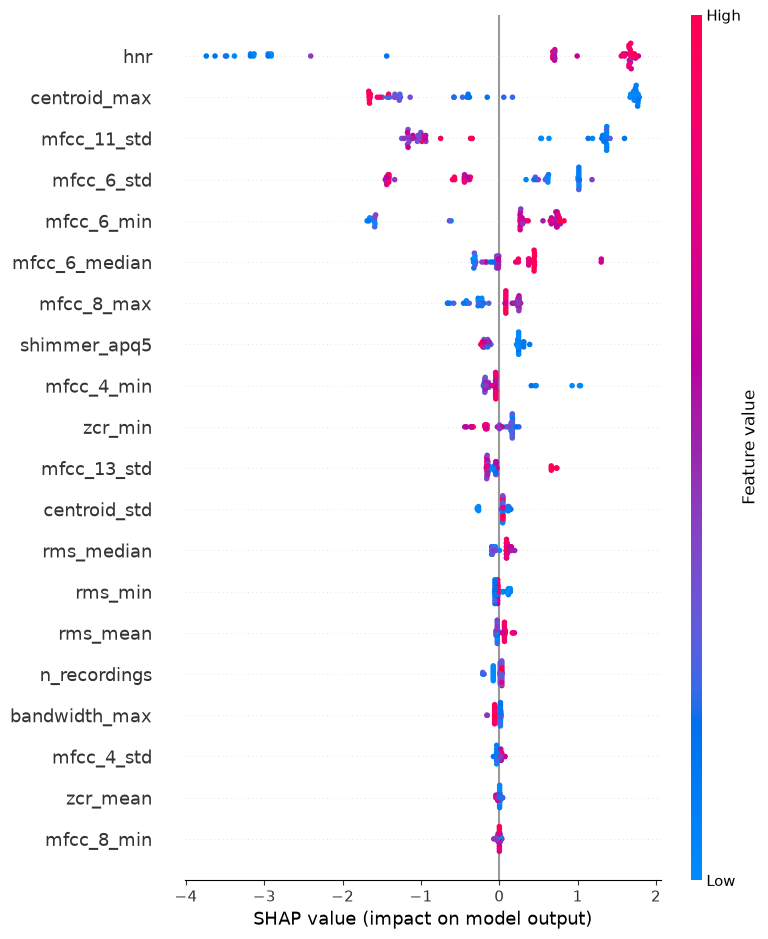

In [64]:
shap.summary_plot(
    shap_values,
    X_train_sel,
    feature_names=selected_features
)

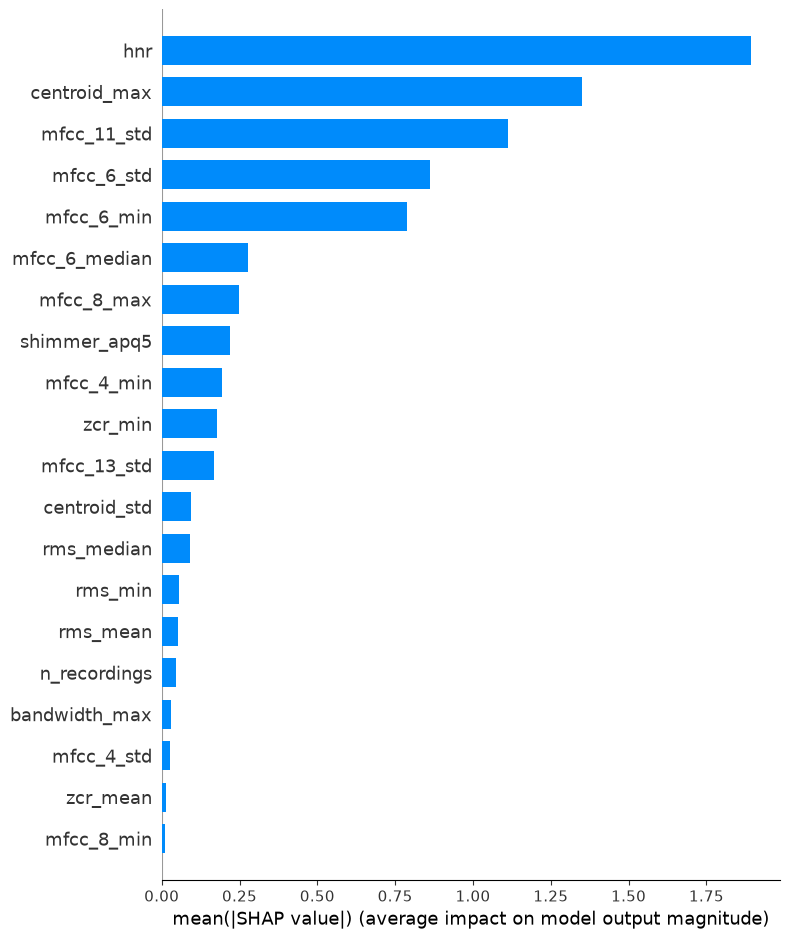

In [65]:
shap.summary_plot(
    shap_values,
    X_train_sel,
    feature_names=selected_features,
    plot_type="bar"
)

In [66]:
import joblib
import json

decision_threshold = 0.5

joblib.dump(
    final_model,
    ARTIFACT_DIR / "speech_italian_lgbm.pkl"
)

joblib.dump(
    cal_model,
    ARTIFACT_DIR / "speech_italian_lgbm_calibrated.pkl"
)

joblib.dump(
    imputer,
    ARTIFACT_DIR / "imputer.pkl"
)

joblib.dump(
    selector,
    ARTIFACT_DIR / "feature_selector.pkl"
)

joblib.dump(
    FEATURE_COLS,
    ARTIFACT_DIR / "feature_cols_full.pkl"
)

joblib.dump(
    selected_features,
    ARTIFACT_DIR / "selected_feature_names.pkl"
)

joblib.dump(
    bootstrap_models,
    ARTIFACT_DIR / "bootstrap_models.pkl"
)

joblib.dump(
    shap_background,
    ARTIFACT_DIR / "shap_background.pkl"
)

joblib.dump(
    bootstrap_auc,
    ARTIFACT_DIR / "validation_auc.pkl"
)

joblib.dump(
    decision_threshold,
    ARTIFACT_DIR / "decision_threshold.pkl"
)

metadata = {
    "model_type": "LightGBM",
    "k_features": len(selected_features),
    "n_subjects_total": int(len(df)),
    "n_subjects_train": int(len(train_idx)),
    "n_subjects_test": int(len(test_idx)),
    "grouped_cv_auc": float(best_auc),
    "test_auc": float(test_auc),
    "bootstrap_auc": float(bootstrap_auc),
    "test_accuracy": float(test_acc),
    "decision_threshold": decision_threshold
}

with open(
    ARTIFACT_DIR / "training_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print("\nArtifacts saved successfully.")


Artifacts saved successfully.
